# Detecção e tratamento de outliers

**Tema:** Preparação de Dados › Dados Faltantes e Outliers

Este notebook compara os métodos de detecção de outlier do `teoria.pdf`,
expõe o problema circular do z-score clássico, e termina com um caso onde
"remover outliers" é exatamente o erro errado a cometer: um cenário de
detecção de fraude.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(88)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Um dataset com outliers de origem conhecida (para variar, sabemos a
verdade)

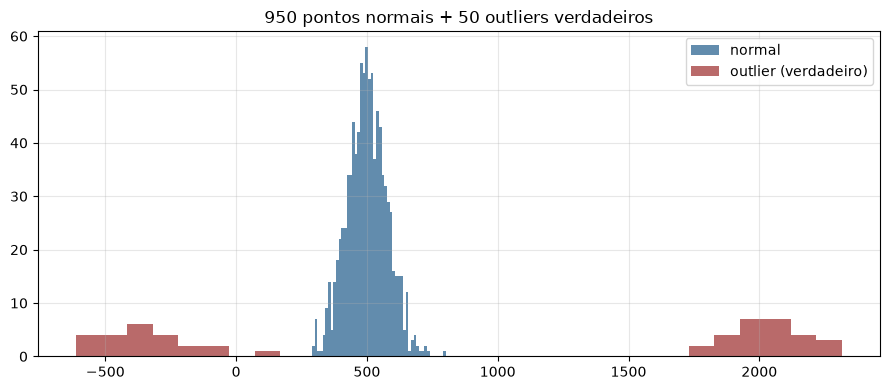

In [2]:
n_normal = 950
n_outliers = 50
valores_normais = rng.normal(500, 80, n_normal)
valores_outliers = rng.choice([rng.normal(2000, 200), rng.normal(-300, 100)],
                              size=n_outliers, replace=True) + rng.normal(0, 150, n_outliers)

valores = np.concatenate([valores_normais, valores_outliers])
eh_outlier_verdadeiro = np.concatenate([np.zeros(n_normal), np.ones(n_outliers)]).astype(bool)

# embaralhar para não deixar os outliers agrupados no fim
ordem = rng.permutation(len(valores))
valores, eh_outlier_verdadeiro = valores[ordem], eh_outlier_verdadeiro[ordem]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(valores[~eh_outlier_verdadeiro], bins=50, alpha=0.7, color=AZUL, label="normal")
ax.hist(valores[eh_outlier_verdadeiro], bins=30, alpha=0.7, color=VERMELHO, label="outlier (verdadeiro)")
ax.legend(); ax.set_title("950 pontos normais + 50 outliers verdadeiros")
plt.tight_layout(); plt.show()

## 2. Z-score clássico: o problema circular

In [3]:
def z_score(x):
    return (x - x.mean()) / x.std(ddof=1)


def z_score_modificado(x):
    mediana = np.median(x)
    mad = np.median(np.abs(x - mediana))
    return 0.6745 * (x - mediana) / mad


z = z_score(valores)
z_mod = z_score_modificado(valores)

deteccao_z = np.abs(z) > 3
deteccao_z_mod = np.abs(z_mod) > 3.5

print(f"z-score clássico   : {deteccao_z.sum()} detectados "
      f"(de {eh_outlier_verdadeiro.sum()} verdadeiros)")
print(f"z-score modificado : {deteccao_z_mod.sum()} detectados "
      f"(de {eh_outlier_verdadeiro.sum()} verdadeiros)")

z-score clássico   : 37 detectados (de 50 verdadeiros)
z-score modificado : 51 detectados (de 50 verdadeiros)


In [4]:
def avalia_deteccao(detectado, verdadeiro):
    vp = (detectado & verdadeiro).sum()
    fp = (detectado & ~verdadeiro).sum()
    fn = (~detectado & verdadeiro).sum()
    precisao = vp / (vp + fp) if (vp + fp) else 0
    recall = vp / (vp + fn) if (vp + fn) else 0
    return precisao, recall


for nome, deteccao in [("z-score clássico", deteccao_z), ("z-score modificado", deteccao_z_mod)]:
    precisao, recall = avalia_deteccao(deteccao, eh_outlier_verdadeiro)
    print(f"{nome:<20s}  precisão={precisao:.2%}   recall={recall:.2%}")

z-score clássico      precisão=100.00%   recall=74.00%
z-score modificado    precisão=98.04%   recall=100.00%


## 3. Tornando o problema circular explícito: outliers extremos "escondem" a si mesmos

Vamos aumentar a magnitude dos outliers e ver o que acontece com cada método.

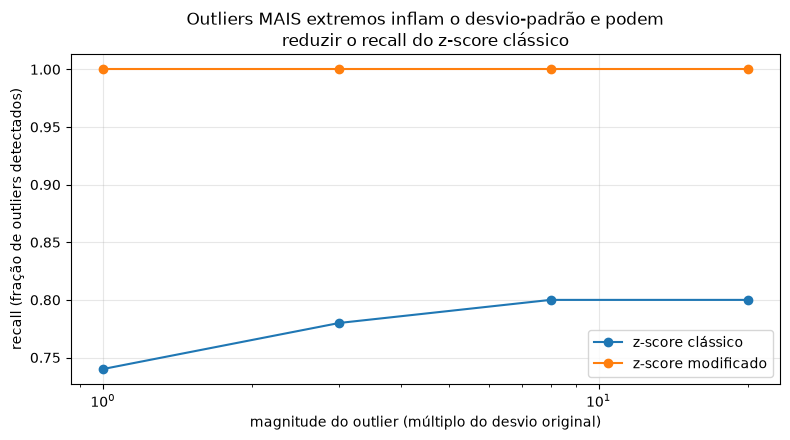

O z-score modificado (mediana/MAD) mantém recall alto porque mediana e
MAD têm ponto de ruptura de 50% — outliers extremos não os deslocam.


In [5]:
magnitudes = [1, 3, 8, 20]
resultado = {"z-score clássico": [], "z-score modificado": []}

for mag in magnitudes:
    valores_teste = valores_normais.copy()
    outliers_ajustados = np.where(
        valores_outliers > valores_normais.mean(),
        valores_normais.mean() + (valores_outliers - valores_normais.mean()) * mag,
        valores_normais.mean() - (valores_normais.mean() - valores_outliers) * mag,
    )
    todos = np.concatenate([valores_teste, outliers_ajustados])
    verdade = np.concatenate([np.zeros(len(valores_teste)), np.ones(len(outliers_ajustados))]).astype(bool)

    det_z = np.abs(z_score(todos)) > 3
    det_zm = np.abs(z_score_modificado(todos)) > 3.5
    resultado["z-score clássico"].append(avalia_deteccao(det_z, verdade)[1])  # recall
    resultado["z-score modificado"].append(avalia_deteccao(det_zm, verdade)[1])

fig, ax = plt.subplots(figsize=(8, 4.5))
for nome, recalls in resultado.items():
    ax.plot(magnitudes, recalls, "o-", label=nome)
ax.set_xlabel("magnitude do outlier (múltiplo do desvio original)")
ax.set_ylabel("recall (fração de outliers detectados)")
ax.set_xscale("log")
ax.set_title("Outliers MAIS extremos inflam o desvio-padrão e podem\n"
             "reduzir o recall do z-score clássico")
ax.legend(); plt.tight_layout(); plt.show()

print("O z-score modificado (mediana/MAD) mantém recall alto porque mediana e")
print("MAD têm ponto de ruptura de 50% — outliers extremos não os deslocam.")

## 4. Regra do IQR: outra opção robusta, e como ela se compara

IQR (fator 1.5)     precisão=92.59%   recall=100.00%


/tmp/ipykernel_20610/753764938.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(valores, vert=True, showmeans=True)


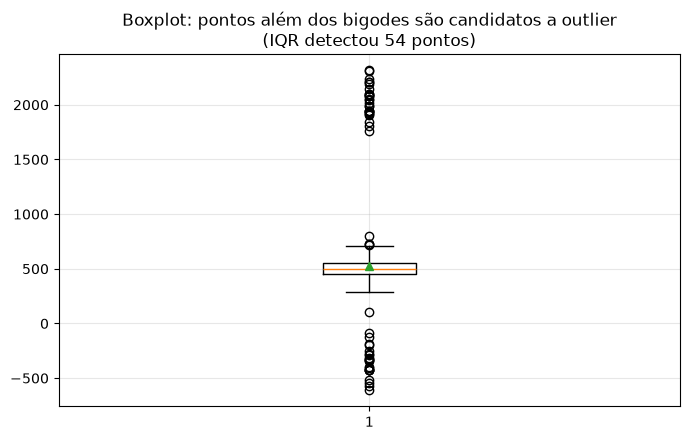

In [6]:
def deteccao_iqr(x, fator=1.5):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    return (x < q1 - fator * iqr) | (x > q3 + fator * iqr)


det_iqr = deteccao_iqr(valores)
precisao_iqr, recall_iqr = avalia_deteccao(det_iqr, eh_outlier_verdadeiro)
print(f"IQR (fator 1.5)     precisão={precisao_iqr:.2%}   recall={recall_iqr:.2%}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot(valores, vert=True, showmeans=True)
ax.set_title(f"Boxplot: pontos além dos bigodes são candidatos a outlier\n"
            f"(IQR detectou {det_iqr.sum()} pontos)")
plt.tight_layout(); plt.show()

## 5. O que fazer depois de detectar: comparar as estratégias de tratamento

Vamos medir o efeito de cada estratégia sobre a média e o desvio-padrão —
as duas estatísticas mais sensíveis a outliers.

estratégia                                      média   desvio-padrão
----------------------------------------------------------------------
original (nada feito)                           522.5           293.8
removendo outliers detectados (IQR)             499.1            74.7
winsorizado (1%/99%)                            522.8           283.6
transformado (log, deslocado p/ positivo)         7.0             0.4


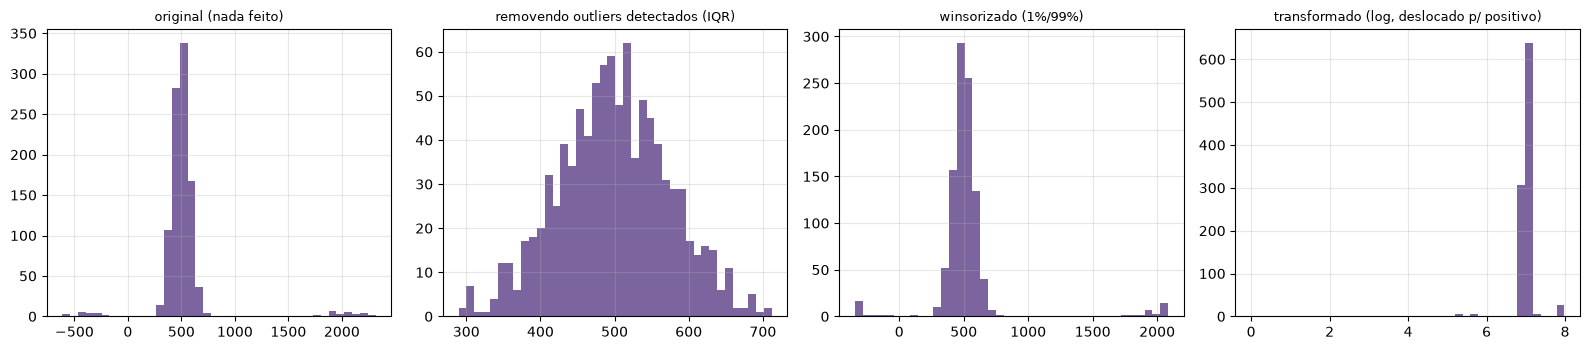

In [7]:
def winsoriza(x, limite_inferior=1, limite_superior=99):
    lo, hi = np.percentile(x, [limite_inferior, limite_superior])
    return np.clip(x, lo, hi)


estrategias = {
    "original (nada feito)": valores,
    "removendo outliers detectados (IQR)": valores[~det_iqr],
    "winsorizado (1%/99%)": winsoriza(valores),
    "transformado (log, deslocado p/ positivo)": np.log(valores - valores.min() + 1),
}

print(f"{'estratégia':<42s} {'média':>10s} {'desvio-padrão':>15s}")
print("-" * 70)
for nome, v in estrategias.items():
    print(f"{nome:<42s} {v.mean():>10.1f} {v.std(ddof=1):>15.1f}")

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, (nome, v) in zip(axes, estrategias.items()):
    ax.hist(v, bins=40, color=ROXO, alpha=0.8)
    ax.set_title(nome, fontsize=9)
plt.tight_layout(); plt.show()

## 6. Quando o outlier É o sinal: um cenário de fraude

Simulação simples: transações normais e transações fraudulentas, onde
fraude se manifesta como valores atipicamente altos. "Remover outliers"
antes de treinar um detector de fraude removeria exatamente a classe que
se quer detectar.

In [8]:
n_transacoes = 5000
valor_normal = rng.lognormal(np.log(80), 0.5, n_transacoes)
eh_fraude = rng.random(n_transacoes) < 0.02
valor_transacao = np.where(
    eh_fraude, valor_normal * rng.uniform(15, 40, n_transacoes), valor_normal)

transacoes = pd.DataFrame({"valor": valor_transacao, "fraude": eh_fraude.astype(int)})

deteccao_outlier_ingenua = deteccao_iqr(transacoes["valor"].to_numpy(), fator=1.5)
print(f"transações sinalizadas como 'outlier' pelo IQR: {deteccao_outlier_ingenua.sum()}")
print(f"dessas, quantas são fraude de verdade: "
      f"{(deteccao_outlier_ingenua & eh_fraude).sum()} de {eh_fraude.sum()} fraudes totais")

fracao_fraude_removida_se_descartar = (
    transacoes.loc[deteccao_outlier_ingenua, "fraude"].sum() / eh_fraude.sum())
print(f"\nSe essas linhas fossem REMOVIDAS do dataset de treino, "
      f"{fracao_fraude_removida_se_descartar:.0%} dos casos de fraude "
      f"desapareceriam com elas.")

transações sinalizadas como 'outlier' pelo IQR: 264
dessas, quantas são fraude de verdade: 120 de 120 fraudes totais

Se essas linhas fossem REMOVIDAS do dataset de treino, 100% dos casos de fraude desapareceriam com elas.


**A decisão certa aqui não é estatística, é de domínio:** esses "outliers"
são a classe positiva de um problema de classificação. O fluxo correto é
manter os pontos, e usar as técnicas do módulo 5 (Dados Desbalanceados) —
pesos de classe, reamostragem, ajuste de limiar — para lidar com a raridade,
não descartar o sinal.

## O que levar deste notebook

- O z-score clássico tem um problema circular: usa média e desvio-padrão que
  os próprios outliers distorcem. Prefira a versão modificada (mediana/MAD)
  ou a regra do IQR, ambas robustas por construção.
- Detectar não é decidir: remover, capar (winsorizar) e transformar (log) têm
  efeitos bem diferentes sobre média e desvio-padrão — e nenhuma é
  universalmente certa.
- Antes de qualquer tratamento automático, pergunte se o "outlier" é erro de
  coleta ou é o próprio fenômeno de interesse (fraude, falha, cliente raro).
  Remover no segundo caso destrói o problema que o modelo deveria resolver.

→ Próximo: o notebook de **exercícios** do módulo.